# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Shafira Nabilazzahra]
- **Email:** [shafiranz04@gmail.com]
- **ID Dicoding:** [shafira_nz]

## Menentukan Pertanyaan Bisnis

- Bagaimana tren perubahan jumlah order setiap bulan dalam periode dataset, dan apakah terdapat pola tertentu seperti peningkatan atau penurunan yang signifikan?
- Bagaimana distribusi total revenue pada setiap kota, dan kota mana yang memiliki kontribusi revenue terbesar dalam periode dataset?
- Produk atau kategori produk mana yang paling diminati dan paling kurang diminati oleh pelanggan berdasarkan jumlah pembelian dan total revenue dalam periode dataset?
- Bagaimana segmentasi pelanggan berdasarkan analisis RFM ke dalam kategori Lost, Low, Medium, High, dan Top, serta bagaimana karakteristik masing-masing segmen dalam periode dataset?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
import zipfile
with zipfile.ZipFile('E-commerce-public-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall()
customers_df = pd.read_csv("E-Commerce Public Dataset/customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
orders_df = pd.read_csv("E-Commerce Public Dataset/orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
order_items_df = pd.read_csv("E-Commerce Public Dataset/order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
products_df = pd.read_csv("E-Commerce Public Dataset/products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Dataset terdiri dari beberapa tabel seperti customers, orders, order_items, dan payments yang saling berelasi.
- Data perlu digabungkan (merge) untuk mendapatkan informasi transaksi yang lengkap.
- Setiap tabel memiliki peran berbeda, misalnya customers untuk profil pengguna dan orders untuk transaksi.

### Assessing Data

#### Menilai tabel `customers_df`

In [ ]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [ ]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


**Insight:**
- Data customers berisi informasi unik setiap pelanggan.
- Tidak ditemukan duplikasi pada customer_id (sudah bersifat unik).
- Tidak terdapat missing values yang signifikan.
- Data sudah cukup bersih dan siap digunakan untuk analisis segmentasi pelanggan.


#### Menilai tabel `orders_df`

In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**
- Terdapat beberapa kolom bertipe waktu seperti order_purchase_timestamp yang masih dalam format object dan perlu dikonversi ke datetime.
- Tidak ditemukan duplikasi pada order_id.
- Data timestamp penting untuk analisis tren waktu (time series).
- Perlu memastikan konsistensi format tanggal sebelum analisis.


#### Menilai tabel `order_items_df`

In [ ]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [ ]:
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**
- Tabel ini berisi detail item dalam setiap order.
- Satu order dapat memiliki lebih dari satu item (relasi one-to-many).
- Tidak ditemukan duplikasi yang tidak wajar.
- Kolom harga (price) dan freight_value penting untuk analisis revenue.


#### Menilai tabel `products_df`

In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**
- Tabel ini berisi informasi terkait produk seperti product_id dan kategori produk.
- Beberapa kolom memiliki missing values, terutama pada atribut deskriptif produk.
- Data kategori produk penting untuk analisis perilaku pembelian berdasarkan kategori.
- Perlu dilakukan penanganan missing values atau penyederhanaan kolom jika tidak digunakan.



### Cleaning Data

In [ ]:
# Memperbaiki tipe data
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB


In [ ]:
# Menghapus missing value pada products
orders_df = orders_df.dropna()
products_df = products_df.dropna()

In [ ]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


In [ ]:
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


**Insight:**
- Dilakukan pengecekan dan penghapusan data yang memiliki missing values untuk memastikan kualitas data tetap baik.
- Kolom bertipe waktu seperti order_purchase_timestamp dikonversi dari tipe data object menjadi datetime.
- Konversi ini bertujuan agar data dapat digunakan untuk analisis berbasis waktu (time series) dan perhitungan RFM.
- Setelah proses cleaning, dataset menjadi lebih bersih, konsisten, dan siap untuk tahap analisis selanjutnya.

## Exploratory Data Analysis (EDA)

### Explore `orders_df`

In [ ]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
18216,317bc187384c65775ea8f3b23aad4acf,88058cff0e6aed321bbe871f86876eb0,delivered,2017-11-17 10:23:33,2017-11-17 14:15:22,2017-11-22 21:48:28,2017-11-24 15:20:00,2017-11-30 00:00:00
93251,8ef55bb7e5a6e757fb880324b4dc284c,6c39ef98910795402cb3b375983b147d,delivered,2017-09-07 17:15:40,2017-09-07 17:30:19,2017-09-08 19:49:55,2017-09-13 16:12:50,2017-09-26 00:00:00
6458,b5fee65bd894e490f09a8b389cce552e,5bed8bf593c7bb615573667c79311ca3,delivered,2017-10-18 00:04:13,2017-10-18 00:14:27,2017-10-20 18:59:57,2017-11-03 21:27:38,2017-11-10 00:00:00
80562,bdce854b86e3fe8851225cb4d17f0776,f3d5f4d7dfe0ba7806d68a521836f436,delivered,2018-05-04 18:09:14,2018-05-04 18:29:58,2018-05-07 15:15:00,2018-05-08 18:12:52,2018-05-21 00:00:00
17178,456ed1919e7baeb18f95d9c1ab8d2cca,125a2560ed26caa1aaa75eebd3f97be1,delivered,2018-04-01 10:01:52,2018-04-03 05:50:29,2018-04-05 22:49:31,2018-04-10 21:37:40,2018-04-18 00:00:00


In [ ]:
orders_df.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,96461,96461,96461,96461,96461,96461,96461,96461
unique,96461,96461,2,NaN,88272,80100,95649,445
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96455,NaN,9,47,3,507
mean,NaN,NaN,NaN,2018-01-01 23:53:26.642249216,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2016-09-15 12:16:38,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2017-09-14 09:28:28,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2018-01-20 19:59:42,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2018-05-05 18:33:24,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,2018-08-29 15:00:37,NaN,NaN,NaN,NaN


In [ ]:
orders_df.order_purchase_timestamp.is_unique

False

In [ ]:
# buat kolom bulan
orders_df['month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

# hitung jumlah transaksi per bulan
monthly_orders = orders_df.groupby('month').size()

monthly_orders.head()

,0
month,
2016-09,1
2016-10,270
2016-12,1
2017-01,748
2017-02,1641


**Insight:**
- Jumlah transaksi per bulan menunjukkan adanya fluktuasi dari waktu ke waktu.
- Terdapat bulan dengan jumlah transaksi yang lebih tinggi dibanding bulan lainnya.
- Hal ini menunjukkan bahwa aktivitas pembelian pelanggan tidak konsisten dan kemungkinan dipengaruhi oleh faktor tertentu seperti promo atau musim tertentu.

### Explore `customers_df`

In [ ]:
customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
74148,41aaf6c5c39d252a49c3dfe5ecd0c9c4,04c0fef9b7d165360bad6e3385e48125,7130,guarulhos,SP
18971,eb97846f551d8d032bca44331f22dcb1,0ed558e285dfa58e23fbbb9c3601a78d,15895,cedral,SP
72517,53744dcf34082ef4cae9cdefb2bbc636,bbe5f9840ea0410a4709264dd7a74609,9725,sao bernardo do campo,SP
62031,ffb0327dd973137e6795f0a714f4aa0e,50c129f15d453b17e041e99f13739525,86020,londrina,PR
59213,dd33e159dda0ff53ee235f422a5db59c,65634ec49e0efdfbe399da96940e5499,13482,limeira,SP


In [ ]:
customers_df.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [ ]:
customers_df.customer_id.duplicated().sum()

np.int64(0)

In [ ]:
customer_unique_in_orders = orders_df.merge(customers_df, on="customer_id")["customer_unique_id"]

customers_df["status"] = customers_df["customer_unique_id"].apply(
    lambda x: "Active" if x in customer_unique_in_orders.values else "Non Active"
)

customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status
4248,84b105f64811531772a6ea55c14129a9,dfc3fffe19ec7d3b45fc10137bb84065,3367,sao paulo,SP,Active
81426,8f56c275bc7f5d95b20b4e961602ab39,9e98e4329d3644ac09aafdcfb03913ec,4456,sao paulo,SP,Active
59289,863b6381550660b774a6f43d857d2b0f,c4601f3d0e8da101aeba12d2ed530285,12270,jambeiro,SP,Active
94165,f88903d440fd26c3aa83f4f8c269c66f,f0ffd8c6cc5ee310933c1b109c3e69f2,34000,nova lima,MG,Active
12361,2a786d13278ec66a602d028cbccde4b6,709d2a72ef3652f89310ced4d363c4d0,45651,ilheus,BA,Active


**Insight:**
- Beberapa kota memiliki jumlah transaksi yang lebih tinggi dibanding kota lainnya.
- Hal ini menunjukkan bahwa pelanggan tidak tersebar merata dan terdapat kota dengan kontribusi transaksi yang dominan.
- Kota dengan jumlah transaksi tinggi berpotensi menjadi target utama dalam strategi pemasaran.

### Menggabungkan `customers_df` dan `orders_df`

In [ ]:
orders_customers_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)
orders_customers_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,Active
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,Active
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,Active
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,Active
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,Active


In [ ]:
orders_customers_df.groupby(by="customer_city").order_id.nunique().sort_values(ascending=False).head(10)

,order_id
customer_city,
sao paulo,15044
rio de janeiro,6603
belo horizonte,2697
brasilia,2071
curitiba,1489
campinas,1406
porto alegre,1341
salvador,1188
guarulhos,1143


In [ ]:
orders_customers_df.groupby(by="order_status").order_id.nunique().sort_values(ascending=False)

,order_id
order_status,
delivered,96455
canceled,6


In [ ]:
orders_customers_df.groupby(by="status").order_id.nunique().sort_values(ascending=False)

,order_id
status,
Active,96461


**Insight:**
- Sebagian besar order berada pada status tertentu (seperti delivered).
- Hal ini menunjukkan bahwa mayoritas transaksi berhasil diselesaikan.
- Namun tetap terdapat beberapa order dengan status lain yang perlu diperhatikan untuk evaluasi operasional.
- Status selain selesai dapat menjadi indikator adanya kendala dalam proses transaksi.

### Explore `products_df`

In [ ]:
products_df.sample(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
24664,47cc9106e1bc828d424f9439933ca075,cama_mesa_banho,55.0,434.0,1.0,1100.0,22.0,18.0,18.0
12460,64473a39b66923a81252bb7150b63663,utilidades_domesticas,45.0,747.0,3.0,525.0,67.0,15.0,14.0
1253,159d2dfef362b9ad87fc748aeca593e8,esporte_lazer,31.0,792.0,3.0,400.0,23.0,20.0,15.0
11749,021d39ee869e87d5288f4e731df4a90e,utilidades_domesticas,44.0,663.0,4.0,10350.0,102.0,15.0,40.0
12721,cdc67f292e1e8ca492ec7b16ab5bf299,cama_mesa_banho,55.0,117.0,2.0,800.0,60.0,8.0,60.0
18686,3089d427128cebffda89d3c8fd04fb90,beleza_saude,63.0,3933.0,1.0,750.0,16.0,16.0,15.0
14516,2d000576ada7098440d09be3e8b6ff5d,informatica_acessorios,33.0,146.0,2.0,700.0,30.0,20.0,30.0
6317,fd925ce72399e23cbc5d75e224fc2b57,informatica_acessorios,59.0,507.0,1.0,100.0,16.0,8.0,12.0
21467,6fa89bbdedf820511d87d6e983c06655,utilidades_domesticas,25.0,500.0,3.0,650.0,22.0,41.0,31.0
22009,b79a274e7373a1bfcbd788a239591dec,perfumaria,46.0,385.0,1.0,350.0,18.0,18.0,18.0


In [ ]:
products_df.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32340,32340,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000
unique,32340,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476592,771.492393,2.188961,2276.956586,30.854545,16.958813,23.208596
std,NaN,NaN,10.245699,635.124831,1.736787,4279.291845,16.955965,13.636115,12.078762
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [ ]:
products_df.groupby(by="product_category_name").agg({
    "product_weight_g": ["min", "max"],
    "product_length_cm": ["min", "max"],
    "product_height_cm": ["min", "max"],
    "product_width_cm": ["min", "max"]
})

product_weight_g          product_length_cm         \
                                       min      max               min    max   
product_category_name                                                          
agro_industria_e_comercio             50.0  30000.0              11.0   99.0   
alimentos                             75.0   8238.0              16.0   44.0   
alimentos_bebidas                     50.0  10800.0              16.0   57.0   
artes                                100.0  15400.0              16.0  100.0   
artes_e_artesanato                   100.0   6850.0              16.0  105.0   
...                                    ...      ...               ...    ...   
sinalizacao_e_seguranca              100.0  27100.0              16.0  100.0   
tablets_impressao_imagem             100.0   1100.0              16.0   60.0   
telefonia                             50.0   8100.0              12.0   40.0   
telefonia_fixa                        50.0   6050.0              14.0  100.0   
utilidades_domesticas                 50.0  30000.0              10.0  105.0   

                          product_height_cm        product_width_cm        
                                        min    max              min   max  
product_category_name                                                      
agro_industria_e_comercio               2.0  105.0             10.0  80.0  
alimentos                               4.0   52.0             11.0  36.0  
alimentos_bebidas                       2.0   40.0             11.0  30.0  
artes                                   2.0   62.0             11.0  70.0  
artes_e_artesanato                      2.0   25.0             11.0  65.0  
...                                     ...    ...              ...   ...  
sinalizacao_e_seguranca                 2.0  105.0             11.0  53.0  
tablets_impressao_imagem                3.0   27.0             11.0  40.0  
telefonia                               2.0   51.0              8.0  30.0  
telefonia_fixa                          2.0   30.0              9.0  33.0  
utilidades_domesticas                   2.0  105.0             11.0  90.0  

[73 rows x 8 columns]

**Insight:**
- Setiap kategori produk memiliki variasi ukuran dan berat yang berbeda.
- Perbedaan ini menunjukkan karakteristik produk yang beragam dalam setiap kategori.
- Informasi ini dapat digunakan untuk analisis logistik seperti pengiriman dan penyimpanan barang.

### Explore `order_items_df`

In [ ]:
order_items_df.sample(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
60289,896be850be41b2bb0343240c4f3dce35,1,d86963242e7dda7eed04f57e492ed655,a3a38f4affed601eb87a97788c949667,2017-02-22 20:21:58,64.90,26.71
4994,0b48910785067fb42fce896aaaf7ce81,2,7bf115809ab249f1bf0fa92d72e0baf8,897060da8b9a21f655304d50fd935913,2018-03-06 02:30:26,40.50,11.85
39499,59d02be1c50fb6e6930cafd6ff6a31e5,1,c4baedd846ed09b85f78a781b522f126,a1043bafd471dff536d0c462352beb48,2017-09-05 14:30:11,120.00,34.20
22040,325a9deca08aa5851eb6eea67f0414aa,1,2903f5a4475454e513a2bdcad950b90f,77530e9772f57a62c906e1c21538ab82,2018-03-27 02:55:49,99.00,20.42
72789,a5f52ebb3569cc7357f500d755314c0d,1,d48bacc1dcd9c86bf1ed4ed2a303336c,9d4db00d65d7760644ac0c14edb5fd86,2018-04-24 05:11:25,42.90,9.44
74891,aa99487411b30032936831e56c42da2f,1,ef9f731f8f63f85ea53e94df375baf54,f5a590cf36251cf1162ea35bef76fe84,2018-06-13 16:19:43,890.00,101.09
29895,43f1558f9eec3596990432207c65c146,1,b5e13c9a353102f79c6206ff5cb61a50,a49928bcdf77c55c6d6e05e09a9b4ca5,2017-09-04 04:35:50,79.90,11.76
18935,2b816c3dd6289435f8cbb71f22f4061f,1,0a23fd10720c5ffc6c7f5e66b0b26ae2,53e4c6e0f4312d4d2107a8c9cddf45cd,2017-08-24 19:10:18,35.99,28.28
32787,4a51f8e9dff86ab803142a930f7866cc,1,e0b9f1ae7c2469feb2555a5d42e2fe53,0f7eea709efdf942b5f95c7516dbacd7,2018-04-17 19:29:44,31.00,18.23
3793,0899b756a6357ed330e0620ad548d70d,1,c201a862c6018d402222594d5229c613,c8b0e2b0a7095e5d8219575d5e7e1181,2017-09-05 02:05:08,117.99,9.64


In [ ]:
order_items_df.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [ ]:
order_items_df.groupby(by="product_id").agg({
    "price": "sum",
    "freight_value": ["min", "max"]
})

price freight_value       
                                     sum           min    max
product_id                                                   
00066f42aeeb9f3007548bb9d3f33c38  101.65         18.59  18.59
00088930e925c41fd95ebfe695fd2655  129.90         13.93  13.93
0009406fd7479715e4bef61dd91f2462  229.00         13.10  13.10
000b8f95fcb9e0096488278317764d19  117.80         19.60  19.60
000d9be29b5207b54e86aa1b1ac54872  199.00         19.27  19.27
...                                  ...           ...    ...
fff6177642830a9a94a0f2cba5e476d1  229.98         17.02  38.39
fff81cc3158d2725c0655ab9ba0f712c   90.00          7.89   7.89
fff9553ac224cec9d15d49f5a263411f   32.00         11.85  11.85
fffdb2d0ec8d6a61f0a0a0db3f25b441  169.95          7.39  18.23
fffe9eeff12fcbd74a2f2b007dde0c58  249.99         53.88  53.88

[32951 rows x 3 columns]

**Insight:**
- Setiap produk memiliki total penjualan (price) yang berbeda-beda.
- Terdapat variasi biaya pengiriman (freight_value) antar produk.
- Hal ini menunjukkan bahwa kontribusi revenue tidak merata di setiap produk.

### Menggabungkan `products_df` dan `order_items_df`

In [ ]:
orders_items_products_df = pd.merge(
    left=products_df,
    right=order_items_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)
orders_items_products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,e17e4f88e31525f7deef66779844ddce,1,5670f4db5b62c43d542e1b2d56b0cf7c,2018-04-30 17:33:54,10.91,7.39
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,5236307716393b7114b53ee991f36956,1,b561927807645834b59ef0d16ba55a24,2018-02-06 19:11:15,248.00,17.99
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,01f66e58769f84129811d43eefd187fb,1,7b07b3c7487f0ea825fc6df75abd658b,2018-07-11 21:30:20,79.80,7.82
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,143d00a4f2dde4e0364ee1821577adb3,1,c510bc1718f0f2961eaa42a23330681a,2018-08-07 09:10:13,112.30,9.54
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,86cafb8794cb99a9b1b77fc8e48fbbbb,1,0be8ff43f22e456b4e0371b2245e4d01,2018-04-17 01:30:23,37.90,8.29


In [ ]:
orders_items_products_df.groupby(by="product_category_name").agg({
    "price": "sum",
    "freight_value": ["min", "max"]
})

price freight_value        
                                 sum           min     max
product_category_name                                     
agro_industria_e_comercio   72530.47          7.39  194.55
alimentos                   29393.41          2.97   58.84
alimentos_bebidas           15179.48          0.76   58.78
artes                       24202.64          7.39  227.66
artes_e_artesanato           1814.01          7.39   68.72
...                              ...           ...     ...
sinalizacao_e_seguranca     21509.23          5.75  299.16
tablets_impressao_imagem     7528.41          1.71   34.49
telefonia                  323667.53          0.01  121.22
telefonia_fixa              59583.00          7.39   77.22
utilidades_domesticas      632248.66          0.02  375.28

[73 rows x 3 columns]

**Insight:**
- Beberapa kategori produk menghasilkan total revenue yang lebih tinggi dibanding kategori lainnya.
- Terdapat perbedaan biaya pengiriman antar kategori produk.
- Kategori dengan revenue tinggi dapat menjadi fokus utama dalam strategi bisnis.

### Explore All Data

In [ ]:
all_df = pd.merge(
    left=orders_customers_df,
    right=orders_items_products_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)
all_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month,customer_unique_id,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_item_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,7c396fd4830fd04220f754e42b4e5bff,...,4.0,500.0,19.0,8.0,13.0,1.0,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,af07308b275d755c9edb36a90c618231,...,1.0,400.0,19.0,13.0,19.0,1.0,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,...,1.0,420.0,24.0,19.0,21.0,1.0,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11,7c142cf63193a1473d2e66489a9ae977,...,3.0,450.0,30.0,10.0,20.0,1.0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,...,4.0,250.0,51.0,15.0,15.0,1.0,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [ ]:
all_df.groupby(by=["customer_city", "product_category_name", "order_status"]).agg({
    "price": "sum"
})


price
customer_city       product_category_name  order_status        
abadia dos dourados cool_stuff             delivered     199.00
                    esporte_lazer          delivered     120.00
                    livros_interesse_geral delivered      39.90
abadiania           eletroportateis        delivered     949.99
abaete              bebes                  delivered      65.00
...                                                         ...
ze doca             bebes                  delivered      74.80
                    esporte_lazer          delivered     149.90
                    ferramentas_jardim     delivered      39.90
                    instrumentos_musicais  delivered     359.00
zortea              informatica_acessorios delivered      69.90

[24918 rows x 1 columns]

**Insight:**
- Kombinasi antara kota, kategori produk, dan status order menunjukkan variasi kontribusi revenue.
- Beberapa kombinasi memberikan kontribusi yang lebih besar dibanding yang lain.
- Hal ini menunjukkan bahwa perilaku pembelian pelanggan berbeda-beda di setiap wilayah dan kategori produk.

In [ ]:
all_df.groupby(by=["month", "product_category_name", "order_status"]).agg({
    "price": "sum"
})

price
month   product_category_name   order_status          
2016-09 beleza_saude            delivered       134.97
2016-10 alimentos               delivered        79.90
        audio                   delivered       156.99
        automotivo              delivered      1128.26
        bebes                   delivered      1371.17
...                                                ...
2018-08 relogios_presentes      delivered     69767.06
        sinalizacao_e_seguranca delivered      1825.59
        telefonia               delivered     36572.91
        telefonia_fixa          delivered      2724.17
        utilidades_domesticas   delivered     58763.36

[1257 rows x 1 columns]

**Insight:**
- Revenue per bulan bervariasi tergantung kategori produk dan status order.
- Terdapat kategori produk tertentu yang mendominasi pada bulan tertentu.
- Hal ini menunjukkan adanya pola musiman dalam pembelian produk.

In [ ]:
all_df.to_csv("all_data.csv", index=False)

## Visualization & Explanatory Analysis

### Pertanyaan 1: **Bagaimana tren perubahan jumlah order setiap bulan dalam periode dataset, dan apakah terdapat pola tertentu seperti peningkatan atau penurunan yang signifikan?**

In [ ]:
all_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month,customer_unique_id,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_item_id,seller_id,shipping_limit_date,price,freight_value
47520,28bb8d06f88bafeaa80c809e2366daa7,799cbb42585f5692863c03135215d730,delivered,2017-10-09 16:08:56,2017-10-09 16:43:53,2017-10-11 17:15:43,2017-10-27 15:53:58,2017-11-14 00:00:00,2017-10,a3a1cb9dcd1acc2bf28f56e42bae977e,...,1.0,200.0,16.0,32.0,11.0,1.0,113e3a788b935f48aad63e1c41dac1bd,2017-10-18 17:37:52,19.83,34.15
63913,373e8a6f20402ca46cedf50241ed878b,641225fde4de7cca971a1d59354adfe5,delivered,2017-12-13 13:52:38,2017-12-14 02:12:37,2017-12-14 18:45:51,2017-12-22 12:42:23,2018-01-09 00:00:00,2017-12,d7b4f3c9c89ba771ef099693c61d7085,...,1.0,541.0,19.0,12.0,16.0,1.0,dbd66278cbfe1aa1000f90a217ca4695,2017-12-20 02:12:37,29.00,14.10
31297,ea6fee69d30e159d8b44c26bd3d8de26,0a7eaf59de0cb85fe7a904ecf2abae88,delivered,2018-04-13 22:01:34,2018-04-14 02:31:39,2018-04-16 18:28:31,2018-04-18 18:56:54,2018-05-02 00:00:00,2018-04,11bf151e14f4e5ce06f54c7eaf33490d,...,3.0,1200.0,42.0,25.0,15.0,1.0,7a67c85e85bb2ce8582c35f2203ad736,2018-04-19 02:15:27,89.99,11.25
9701,78219cc6b17d2b84d847bbf8b470316c,1c0f0ab71b8207131776a38cc59cd4bd,delivered,2018-07-13 20:08:35,2018-07-13 20:23:54,2018-07-14 08:31:00,2018-07-20 18:03:30,2018-07-27 00:00:00,2018-07,21cdfc6b2c123f648c56fc6080a929fb,...,1.0,950.0,45.0,15.0,35.0,1.0,4a3ca9315b744ce9f8e9374361493884,2018-07-17 20:23:54,69.90,14.80
12800,b7a77aac1be341d2f9009b231cd3b4e8,e43558b2abdd406058436512ebe8b58c,delivered,2017-11-23 21:15:56,2017-11-23 21:27:42,2017-11-29 22:51:28,2018-01-05 17:23:22,2017-12-19 00:00:00,2017-11,d141f28ea7b53df409e7a9a466858d33,...,1.0,14950.0,77.0,20.0,53.0,1.0,855668e0971d4dfd7bef1b6a4133b41b,2017-11-29 21:27:42,119.99,53.22


In [ ]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02


In [ ]:
all_df['month'] = all_df['month'].astype(str)
all_df['month'] = pd.to_datetime(all_df['month'])

monthly_orders_df = all_df.set_index('month').resample('M').agg({
    "order_id": "nunique",
    "price": "sum"
})

monthly_orders_df.head()

/tmp/ipykernel_1508/2792524768.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = all_df.set_index('month').resample('M').agg({


,order_id,price
month,,
2016-09-30,1,134.97
2016-10-31,270,40875.41
2016-11-30,0,0.00
2016-12-31,1,10.90
2017-01-31,748,108174.83


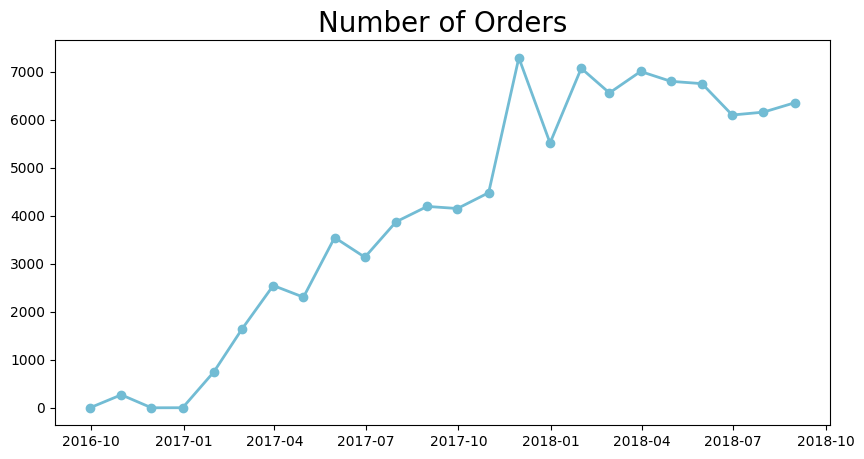

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_orders_df["order_id"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)
plt.title("Number of Orders", loc="center", fontsize=20)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

**Insight:**
- Jumlah transaksi per bulan menunjukkan pola fluktuatif dari waktu ke waktu.
- Terdapat beberapa bulan dengan peningkatan transaksi yang cukup signifikan dibanding bulan lainnya.
- Hal ini menunjukkan bahwa aktivitas pembelian pelanggan tidak stabil dan kemungkinan dipengaruhi oleh faktor seperti promo atau musim tertentu.

### Pertanyaan 2: **Bagaimana distribusi total revenue pada setiap kota, dan kota mana yang memiliki kontribusi revenue terbesar dalam periode dataset?**

In [ ]:
city_revenue_df = all_df.groupby('customer_city').agg({
    "price": "sum"
}).sort_values(by="price", ascending=False)

top_city_revenue = city_revenue_df.head(10)

top_city_revenue.head(10)

,price
customer_city,
sao paulo,1832093.12
rio de janeiro,944995.50
belo horizonte,341828.06
brasilia,293252.80
curitiba,204162.91
campinas,182551.79
porto alegre,178542.77
salvador,170692.53
guarulhos,137440.48


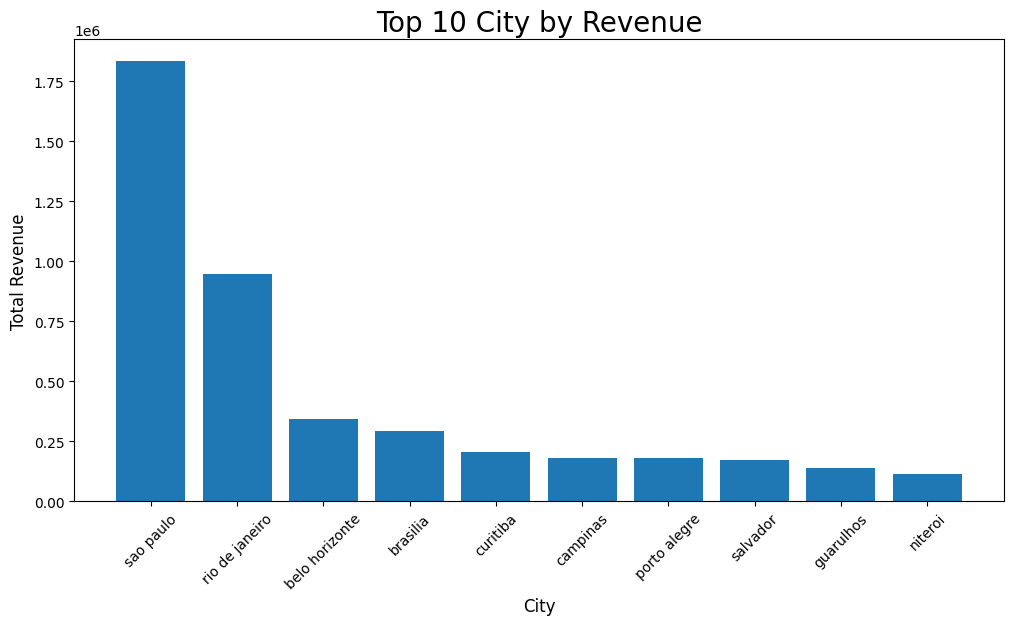

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(
    top_city_revenue.index,
    top_city_revenue["price"]
)

plt.title("Top 10 City by Revenue", fontsize=20)
plt.xlabel("City", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Terdapat beberapa kota dengan total revenue yang jauh lebih tinggi dibanding kota lainnya.
- Kota dengan revenue tertinggi menjadi kontributor utama terhadap pendapatan bisnis.
- Perbedaan ini menunjukkan bahwa daya beli atau jumlah transaksi di setiap kota tidak merata.
- Kota dengan revenue tinggi dapat menjadi fokus utama dalam strategi pemasaran, sedangkan kota dengan revenue rendah memiliki potensi untuk dikembangkan lebih lanjut.

### Pertanyaan 3: **Produk atau kategori produk mana yang paling diminati dan paling kurang diminati oleh pelanggan berdasarkan jumlah pembelian dan total revenue dalam periode dataset?**

In [ ]:
sum_order_items_df = all_df.groupby("product_category_name")["order_item_id"] \
    .count() \
    .sort_values(ascending=False) \
    .reset_index()

sum_order_items_df.head(10)

,product_category_name,order_item_id
0,cama_mesa_banho,10952
1,beleza_saude,9467
2,esporte_lazer,8429
3,moveis_decoracao,8156
4,informatica_acessorios,7643
5,utilidades_domesticas,6795
6,relogios_presentes,5857
7,telefonia,4428
8,ferramentas_jardim,4267
9,automotivo,4139


/tmp/ipykernel_1508/3471990291.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="order_item_id", y="product_category_name", data=sum_order_items_df.head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_1508/3471990291.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="order_item_id", y="product_category_name", data=sum_order_items_df.sort_values(by="order_item_id", ascending=True).head(5), palette=colors, ax=ax[1])


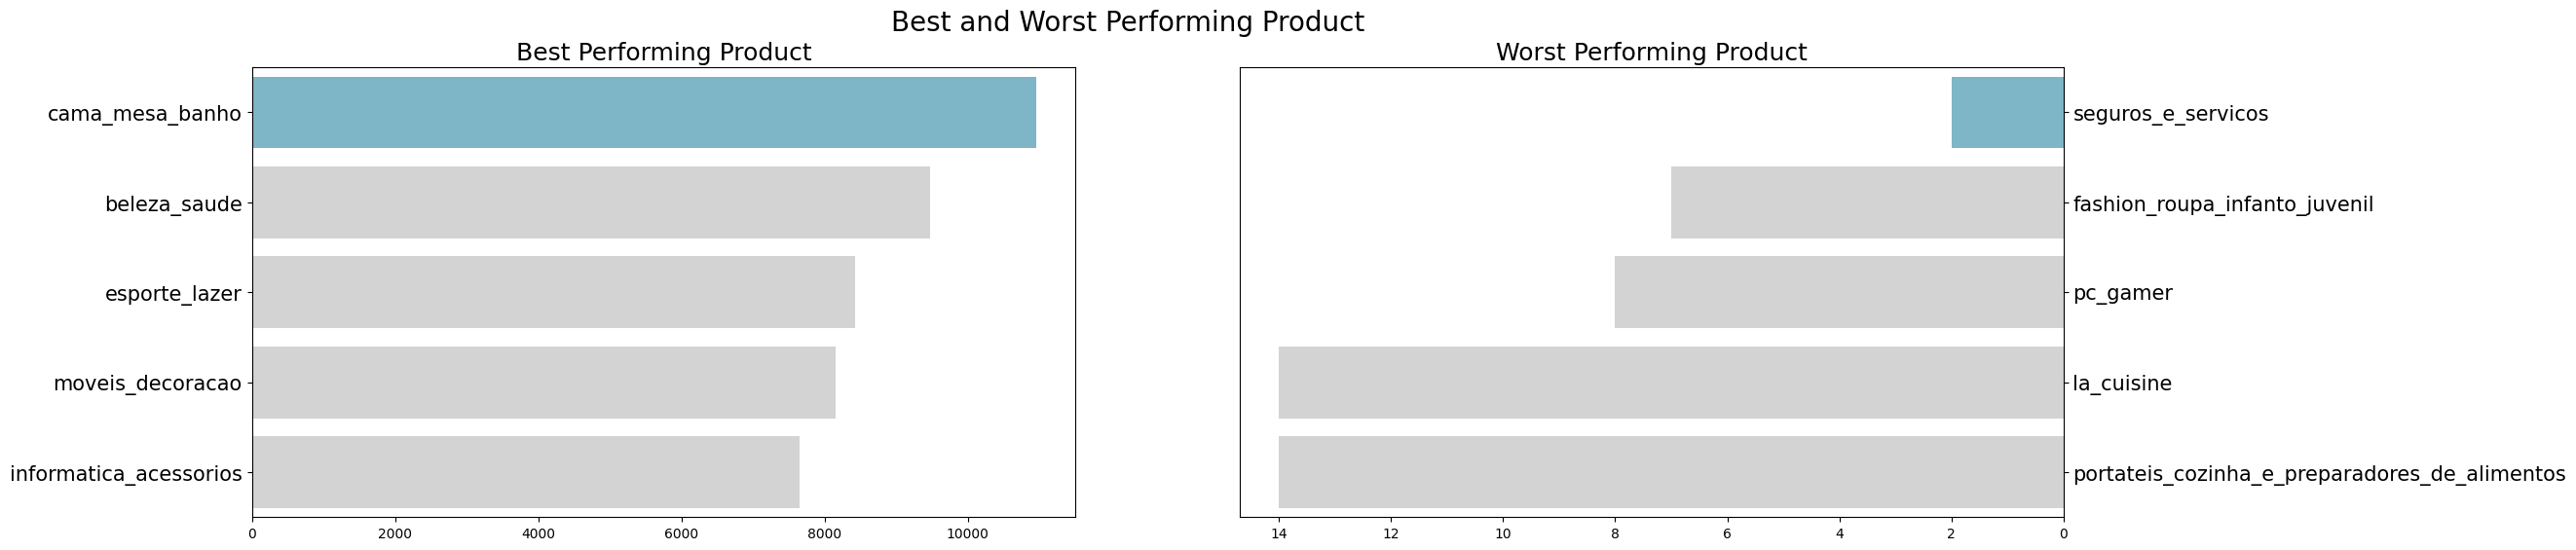

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="order_item_id", y="product_category_name", data=sum_order_items_df.head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Best Performing Product", loc="center", fontsize=18)
ax[0].tick_params(axis ='y', labelsize=15)

sns.barplot(x="order_item_id", y="product_category_name", data=sum_order_items_df.sort_values(by="order_item_id", ascending=True).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Product", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Best and Worst Performing Product", fontsize=20)
plt.show()

**Insight:**
- Terdapat beberapa kategori produk yang memiliki jumlah penjualan dan total revenue tertinggi dibandingkan kategori lainnya.
- Produk-produk ini menunjukkan tingkat minat yang tinggi dari pelanggan dan menjadi kontributor utama terhadap pendapatan bisnis.
- Di sisi lain, terdapat kategori produk dengan jumlah pembelian dan revenue yang rendah, yang menunjukkan kurangnya minat pelanggan terhadap produk tersebut.
- Perbedaan ini menunjukkan bahwa tidak semua produk memiliki performa yang sama di pasar.
- Produk dengan performa terbaik (best product) dapat dijadikan fokus utama dalam strategi pemasaran dan pengembangan bisnis, sedangkan produk dengan performa rendah (worst product) perlu dievaluasi, baik dari segi harga, kualitas, maupun strategi promosi.

### Pertanyaan 4: **Bagaimana segmentasi pelanggan berdasarkan analisis RFM ke dalam kategori Lost, Low, Medium, High, dan Top, serta bagaimana karakteristik masing-masing segmen dalam periode dataset?**

In [ ]:
rfm_df = all_df.groupby(by="customer_id", as_index=False).agg({
    "month": "max", #mengambil tanggal order terakhir
    "order_id": "nunique",
    "price": "sum"
})
rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]
rfm_df.head()


,customer_id,max_order_timestamp,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,2017-11-01,1,89.80
1,000161a058600d5901f007fab4c27140,2017-07-01,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-01,1,179.99
3,0002414f95344307404f0ace7a26f1d5,2017-08-01,1,149.90
4,000379cdec625522490c315e70c7a9fb,2018-04-01,1,93.00


In [ ]:
rfm_df["max_order_timestamp"] = pd.to_datetime(rfm_df["max_order_timestamp"])
recent_date = pd.to_datetime(orders_df["order_purchase_timestamp"]).max()
rfm_df["recency"] = (recent_date - rfm_df["max_order_timestamp"]).dt.days
rfm_df.head()

,customer_id,max_order_timestamp,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,2017-11-01,1,89.80,301
1,000161a058600d5901f007fab4c27140,2017-07-01,1,54.90,424
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-01,1,179.99,574
3,0002414f95344307404f0ace7a26f1d5,2017-08-01,1,149.90,393
4,000379cdec625522490c315e70c7a9fb,2018-04-01,1,93.00,150


In [ ]:
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)
rfm_df.head()

,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,89.80,301
1,000161a058600d5901f007fab4c27140,1,54.90,424
2,0001fd6190edaaf884bcaf3d49edf079,1,179.99,574
3,0002414f95344307404f0ace7a26f1d5,1,149.90,393
4,000379cdec625522490c315e70c7a9fb,1,93.00,150


In [ ]:
rfm_df.describe()

,frequency,monetary,recency
count,96461.0,96461.000000,96461.000000
mean,1.0,135.250879,254.156478
std,0.0,208.078681,153.047788
min,1.0,0.000000,28.000000
25%,1.0,44.950000,120.000000
50%,1.0,84.900000,240.000000
75%,1.0,149.900000,362.000000
max,1.0,13440.000000,727.000000


In [ ]:
rfm_df['r_rank'] = rfm_df['recency'].rank(ascending=False)
rfm_df['f_rank'] = rfm_df['frequency'].rank(ascending=True)
rfm_df['m_rank'] = rfm_df['monetary'].rank(ascending=True)

rfm_df.head()

,customer_id,frequency,monetary,recency,r_rank,f_rank,m_rank
0,00012a2ce6f8dcda20d059ce98491703,1,89.80,301,34526.5,48231.0,50124.0
1,000161a058600d5901f007fab4c27140,1,54.90,424,16126.5,48231.0,31534.0
2,0001fd6190edaaf884bcaf3d49edf079,1,179.99,574,1841.0,48231.0,78649.5
3,0002414f95344307404f0ace7a26f1d5,1,149.90,393,20159.0,48231.0,72481.0
4,000379cdec625522490c315e70c7a9fb,1,93.00,150,67710.5,48231.0,52502.5


In [ ]:
# normalizing the rank of the customers
rfm_df['r_rank_norm'] = (rfm_df['r_rank']/rfm_df['r_rank'].max())*100
rfm_df['f_rank_norm'] = (rfm_df['f_rank']/rfm_df['f_rank'].max())*100
rfm_df['m_rank_norm'] = (rfm_df['m_rank']/rfm_df['m_rank'].max())*100

rfm_df.drop(columns=['r_rank', 'f_rank', 'm_rank'], inplace=True)

rfm_df.head()

,customer_id,frequency,monetary,recency,r_rank_norm,f_rank_norm,m_rank_norm
0,00012a2ce6f8dcda20d059ce98491703,1,89.80,301,37.011449,100.0,51.962969
1,000161a058600d5901f007fab4c27140,1,54.90,424,17.287160,100.0,32.690932
2,0001fd6190edaaf884bcaf3d49edf079,1,179.99,574,1.973501,100.0,81.535025
3,0002414f95344307404f0ace7a26f1d5,1,149.90,393,21.609888,100.0,75.140212
4,000379cdec625522490c315e70c7a9fb,1,93.00,150,72.583775,100.0,54.428733


In [ ]:
rfm_df['RFM_score'] = 0.15*rfm_df['r_rank_norm']+0.28 * \
    rfm_df['f_rank_norm']+0.57*rfm_df['m_rank_norm']
rfm_df['RFM_score'] *= 0.05
rfm_df = rfm_df.round(2)
rfm_df[['customer_id', 'RFM_score']].head(7)

,customer_id,RFM_score
0,00012a2ce6f8dcda20d059ce98491703,3.16
1,000161a058600d5901f007fab4c27140,2.46
2,0001fd6190edaaf884bcaf3d49edf079,3.74
3,0002414f95344307404f0ace7a26f1d5,3.70
4,000379cdec625522490c315e70c7a9fb,3.50
5,0004164d20a9e969af783496f3408652,2.54
6,000419c5494106c306a97b5635748086,2.40


In [ ]:
rfm_df["customer_segment"] = np.where(
    rfm_df['RFM_score'] > 4.5, "Top customers", (np.where(
        rfm_df['RFM_score'] > 4, "High value customer",(np.where(
            rfm_df['RFM_score'] > 3, "Medium value customer", np.where(
                rfm_df['RFM_score'] > 1.6, 'Low value customers', 'lost customers'))))))

rfm_df[['customer_id', 'RFM_score', 'customer_segment']].head(20)

,customer_id,RFM_score,customer_segment
0,00012a2ce6f8dcda20d059ce98491703,3.16,Medium value customer
1,000161a058600d5901f007fab4c27140,2.46,Low value customers
2,0001fd6190edaaf884bcaf3d49edf079,3.74,Medium value customer
3,0002414f95344307404f0ace7a26f1d5,3.70,Medium value customer
4,000379cdec625522490c315e70c7a9fb,3.50,Medium value customer
5,0004164d20a9e969af783496f3408652,2.54,Low value customers
6,000419c5494106c306a97b5635748086,2.40,Low value customers
7,00046a560d407e99b969756e0b10f282,3.64,Medium value customer
8,00050bf6e01e69d5c0fd612f1bcfb69c,2.84,Low value customers
9,000598caf2ef4117407665ac33275130,4.98,Top customers


In [ ]:
customer_segment_df = rfm_df.groupby(by="customer_segment", as_index=False).customer_id.nunique()
customer_segment_df

,customer_segment,customer_id
0,High value customer,15798
1,Low value customers,40291
2,Medium value customer,33524
3,Top customers,5787
4,lost customers,1061


In [ ]:
customer_segment_df['customer_segment'] = pd.Categorical(customer_segment_df['customer_segment'], [
    "lost customers", "Low value customers", "Medium value customer",
    "High value customer", "Top customers"
])

/tmp/ipykernel_3407/1016365800.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


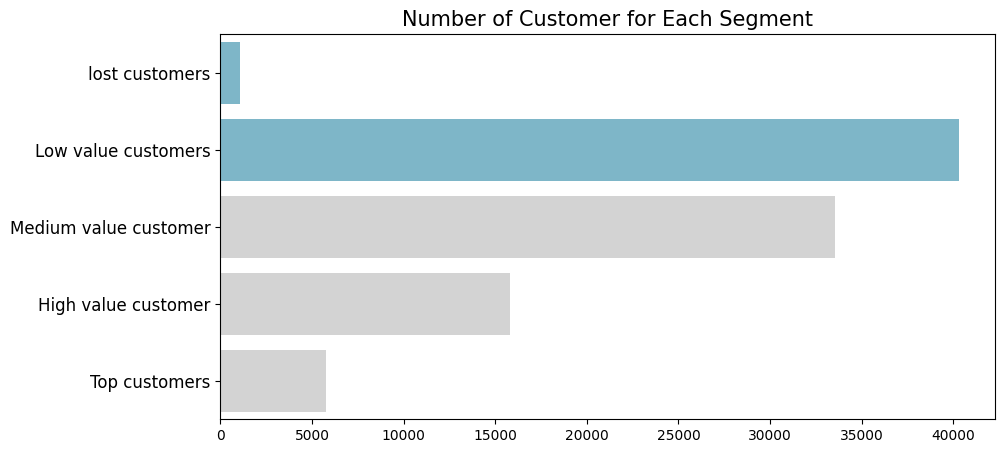

In [ ]:
plt.figure(figsize=(10, 5))
colors_ = ["#72BCD4", "#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="customer_id",
    y="customer_segment",
    data=customer_segment_df.sort_values(by="customer_segment", ascending=False),
    palette=colors_
)
plt.title("Number of Customer for Each Segment", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis='y', labelsize=12)
plt.show()

**Insight:**
- Pelanggan berhasil dikelompokkan ke dalam lima kategori yaitu Lost, Low, Medium, High, dan Top berdasarkan nilai RFM.
- Segmen Top dan High merupakan pelanggan dengan frekuensi transaksi dan total pengeluaran yang tinggi, sehingga menjadi kontributor utama terhadap revenue.
- Segmen Medium menunjukkan pelanggan dengan aktivitas transaksi yang cukup stabil namun belum maksimal.
- Segmen Low memiliki frekuensi dan nilai transaksi yang rendah, sehingga kontribusinya terhadap bisnis masih terbatas.
- Segmen Lost merupakan pelanggan yang sudah lama tidak melakukan transaksi, ditunjukkan oleh nilai recency yang tinggi.
- Pelanggan pada segmen Top dan High perlu dipertahankan dengan strategi loyalitas.
- Pelanggan pada segmen Medium dapat ditingkatkan menjadi pelanggan bernilai tinggi dengan strategi pemasaran yang tepat.
- Pelanggan pada segmen Low dan Lost perlu diberikan perhatian khusus untuk meningkatkan kembali aktivitas transaksi.

## Conclusion

### 1. Bagaimana tren perubahan jumlah order setiap bulan dalam periode dataset, dan apakah terdapat pola tertentu seperti peningkatan atau penurunan yang signifikan?
**Kesimpulan:**
- Jumlah transaksi setiap bulan menunjukkan pola fluktuatif dengan adanya periode peningkatan dan penurunan pada periode oktober 2017 hingga januari 2018.
- Hal ini menunjukkan bahwa aktivitas pembelian pelanggan tidak konsisten sepanjang waktu.

**Rekomendasi Bisnis:**
- Melakukan analisis lebih lanjut terhadap periode dengan peningkatan transaksi untuk mengidentifikasi faktor pendorong (misalnya promo atau event tertentu).
- Mengoptimalkan strategi marketing pada periode dengan transaksi rendah, seperti memberikan diskon atau campaign khusus.
- Menyesuaikan perencanaan stok dan operasional berdasarkan pola tren transaksi.

---

### 2.  Bagaimana distribusi total revenue pada setiap kota, dan kota mana yang memiliki kontribusi revenue terbesar dalam periode dataset?
**Kesimpulan:**
- Terdapat beberapa kota yang memberikan kontribusi revenue jauh lebih besar dibanding kota lainnya (sao paulo).
- Hal ini menunjukkan bahwa distribusi pelanggan dan daya beli tidak merata di setiap wilayah.

**Rekomendasi Bisnis:**
- Memfokuskan strategi pemasaran pada kota dengan revenue tinggi untuk mempertahankan performa.
- Mengembangkan pasar di kota dengan revenue rendah melalui promosi atau ekspansi.
- Menyesuaikan strategi distribusi dan logistik berdasarkan wilayah dengan permintaan tinggi.

---

### 3. Produk atau kategori produk mana yang paling diminati dan paling kurang diminati oleh pelanggan berdasarkan jumlah pembelian dan total revenue dalam periode dataset?
**Kesimpulan:**
- Beberapa kategori produk memiliki tingkat penjualan dan revenue yang tinggi sehingga menjadi produk unggulan (cama_mesa_banho).
- Sebaliknya, terdapat produk dengan performa rendah yang kurang diminati oleh pelanggan (seguros_e_servicos).

**Rekomendasi Bisnis:**
- Memprioritaskan promosi dan ketersediaan stok pada produk dengan performa terbaik.
- Mengevaluasi produk dengan performa rendah dari segi harga, kualitas, dan strategi pemasaran.
- Mengembangkan bundling atau diskon untuk meningkatkan penjualan produk yang kurang diminati.

---

### 4. Bagaimana segmentasi pelanggan berdasarkan analisis RFM ke dalam kategori Lost, Low, Medium, High, dan Top, serta bagaimana karakteristik masing-masing segmen dalam periode dataset?
**Kesimpulan:**
- Pelanggan terbagi menjadi lima segmen yaitu Lost, Low, Medium, High, dan Top berdasarkan nilai Recency, Frequency, dan Monetary.
- Segmen Top: Pelanggan dengan frekuensi transaksi tinggi, nilai belanja besar, dan masih aktif (recency rendah). Merupakan pelanggan paling bernilai bagi bisnis.
- Segmen High: Pelanggan dengan frekuensi dan nilai transaksi tinggi, namun tidak seaktif segmen Top.
- Segmen Medium: Pelanggan dengan aktivitas transaksi yang cukup stabil, namun kontribusi revenue masih sedang.
- Segmen Low: Pelanggan dengan frekuensi dan nilai transaksi rendah, serta kontribusi kecil terhadap revenue.
- Segmen Lost: Pelanggan yang sudah lama tidak melakukan transaksi (recency tinggi) dan berisiko tidak kembali.

**Rekomendasi Bisnis:**
- Memberikan program loyalitas dan reward untuk mempertahankan pelanggan Top dan High.
- Meningkatkan engagement pelanggan Medium agar naik ke segmen High.
- Memberikan promosi atau insentif untuk mendorong pelanggan Low agar lebih aktif.
- Melakukan re-engagement campaign (diskon, email marketing) untuk menarik kembali pelanggan Lost.